In [7]:
import pandas as pd
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

# 1. โหลดข้อมูล (ใช้ไฟล์ที่ balance มาแล้ว)
df = pd.read_csv('data/cleaned_features_balance.csv')
X = df.drop(columns=['Target_Dangerous'])
if 'AnimalName' in X.columns: X = X.drop(columns=['AnimalName'])
y = df['Target_Dangerous']

# 2. แบ่งข้อมูล
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"✅ Data Loaded & Balanced: {X_train.shape[0]} samples for training.")
print(f"📊 Class Distribution - 0: {sum(y_train==0)}, 1: {sum(y_train==1)}")

✅ Data Loaded & Balanced: 1022 samples for training.
📊 Class Distribution - 0: 367, 1: 655


In [8]:
# สร้างโฟลเดอร์เก็บโมเดล
model_path = 'models/decision_tree'
if not os.path.exists(model_path): os.makedirs(model_path)

# เทรน Decision Tree 
# เราใช้ class_weight='balanced' เผื่อไว้นิดหน่อยหากสัดส่วนไม่เป๊ะ 1:1
model = DecisionTreeClassifier(
    max_depth=5,           # กำหนดความลึก 5 ชั้นเพื่อให้เห็นภาพตรรกะชัดเจน
    min_samples_leaf=5,    # ป้องกันไม่ให้สร้างกิ่งจากข้อมูลที่น้อยเกินไป
    random_state=42,
    class_weight='balanced' 
)

print("🚀 Training Decision Tree Model...")
model.fit(X_train, y_train)

# บันทึกโมเดล
joblib.dump(model, f'{model_path}/animal_risk_tree_model.pkl')
joblib.dump(X.columns.tolist(), f'{model_path}/feature_columns.pkl')
print(f"💾 Model saved at: {model_path}")

🚀 Training Decision Tree Model...
💾 Model saved at: models/decision_tree


C:\Users\user\AppData\Local\Temp\ipykernel_34184\1418082563.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')


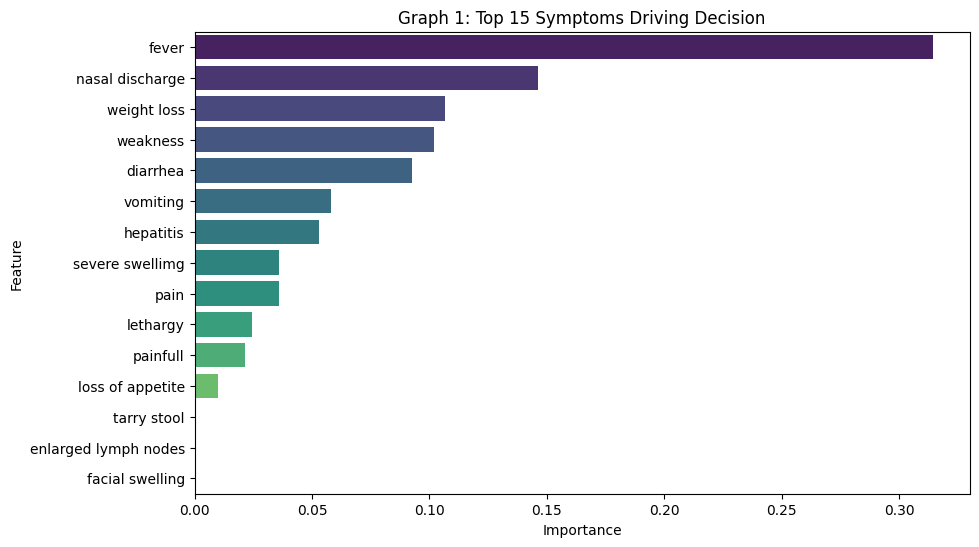

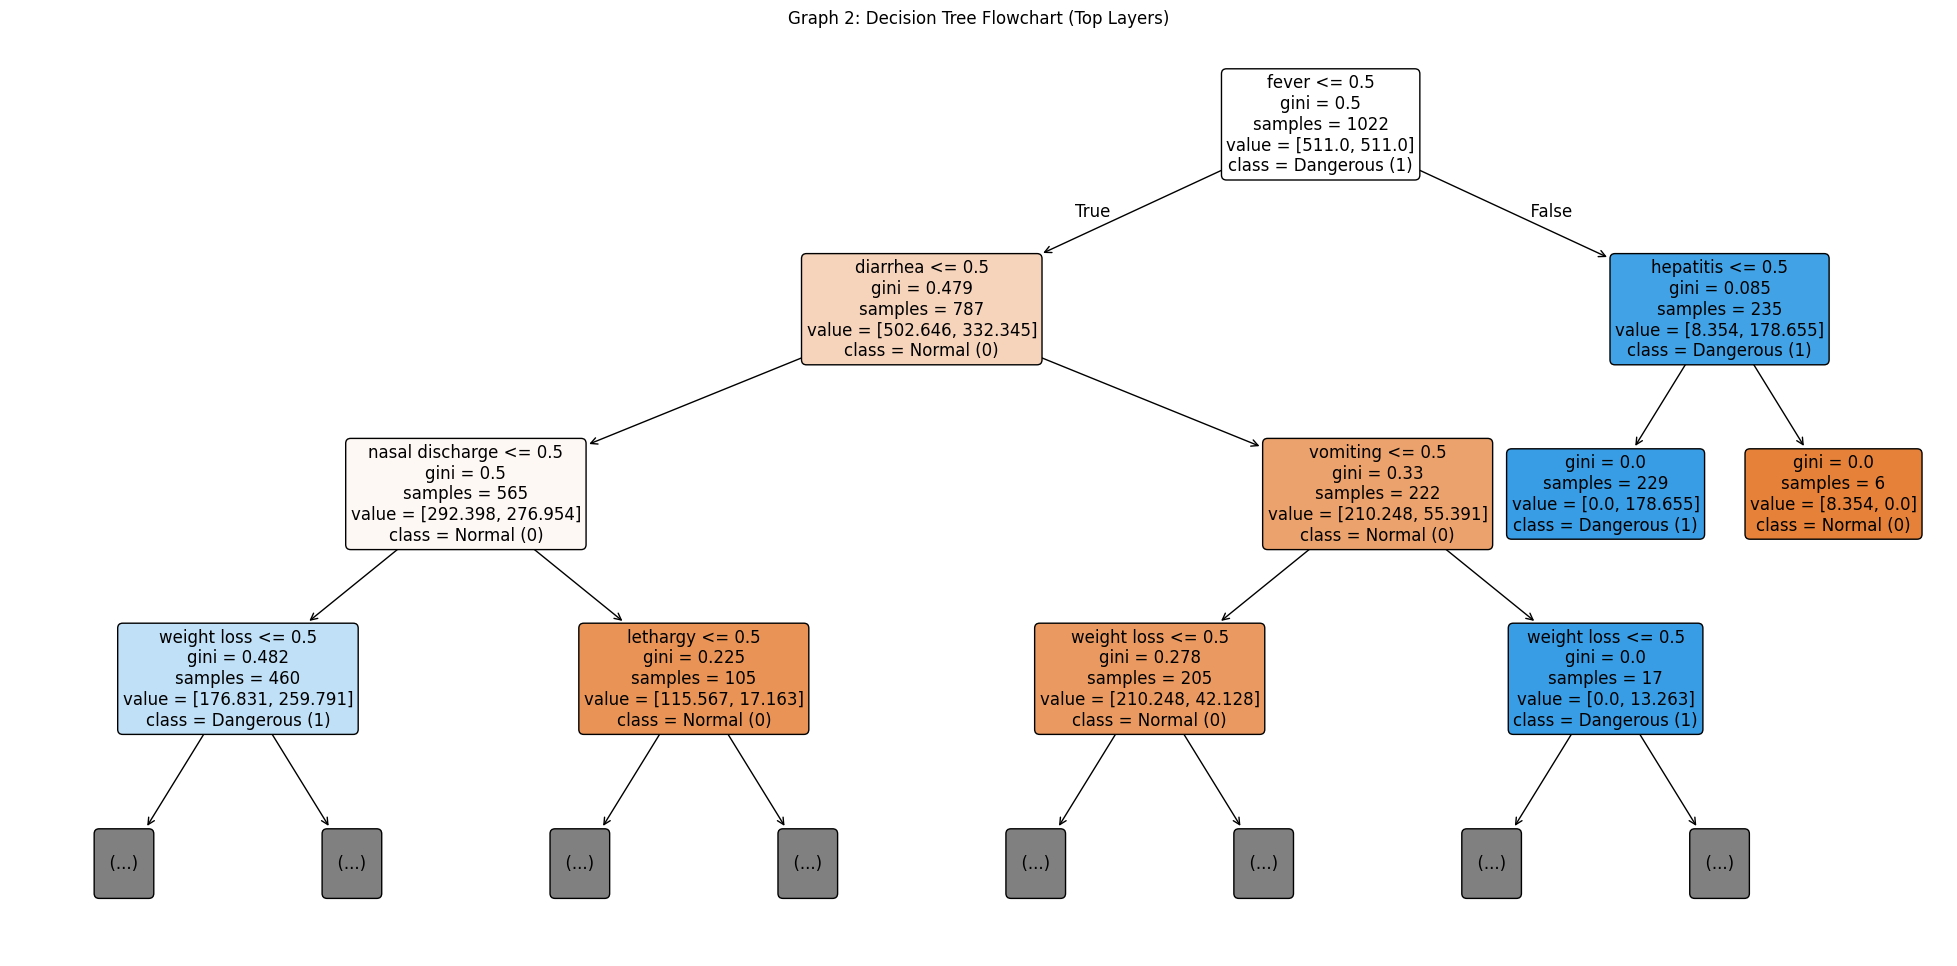

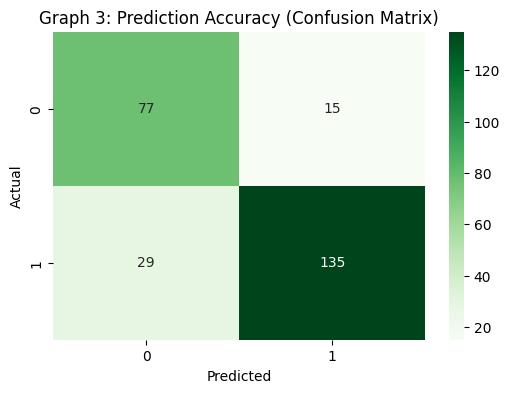

In [ ]:
# --- Graph 1: Feature Importance ---
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances, palette='viridis')
plt.title('Graph 1: Top 15 Symptoms Driving Decision')
plt.show()

# --- Graph 2: Decision Tree Diagram (Full Visualization) ---
plt.figure(figsize=(25, 12))
plot_tree(model, 
          feature_names=X.columns.tolist(), 
          class_names=['Normal (0)', 'Dangerous (1)'], 
          filled=True, 
          rounded=True, 
          fontsize=12,
          max_depth=3) # โชว์แค่ 3 ชั้นแรกเพื่อความสวยงาม (ในโมเดลจริงลึก 5)
plt.title('Graph 2: Decision Tree Flowchart (Top Layers)')
plt.show()

# --- Graph 3: Confusion Matrix ---
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [10]:
print("📊 Classification Report:")
print(classification_report(y_test, y_pred))

# แสดงผลเป็นกฎ (Rules) เผื่อนำไปเขียนโปรแกรมต่อ
from sklearn.tree import export_text
rules = export_text(model, feature_names=X.columns.tolist())
print("\n📜 Logic Rules extracted from Tree:")
print(rules[:1000]) # แสดง 1000 ตัวอักษรแรก

📊 Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.84      0.78        92
           1       0.90      0.82      0.86       164

    accuracy                           0.83       256
   macro avg       0.81      0.83      0.82       256
weighted avg       0.84      0.83      0.83       256


📜 Logic Rules extracted from Tree:
|--- fever <= 0.50
|   |--- diarrhea <= 0.50
|   |   |--- nasal discharge <= 0.50
|   |   |   |--- weight loss <= 0.50
|   |   |   |   |--- weakness <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- weakness >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- weight loss >  0.50
|   |   |   |   |--- pain <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- pain >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- nasal discharge >  0.50
|   |   |   |--- lethargy <= 0.50
|   |   |   |   |--- painfull <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- painfull >  